<a href="https://colab.research.google.com/github/Ashi743/PYTORCH-DEEP-LEARNING/blob/main/ANN_GPU_OPTIMIZE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

import kagglehub

# Download latest version
path = kagglehub.dataset_download("xiaoqingjiang/fashionmnist")

print("Path to dataset files:", path)
# Load the latest version
import pandas as pd
import os

# List contents of the directory to find the CSV file
files_in_path = os.listdir(path)
csv_file = None
for file in files_in_path:
    if file.endswith('.csv'):
        csv_file = file
        break

if csv_file:
    full_csv_path = os.path.join(path, csv_file)
    df = pd.read_csv(full_csv_path)
else:
    print(f"No CSV file found in the directory: {path}")



Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [2]:
df10k= df.copy()

In [3]:
csv_files= []
for file in files_in_path:
    if file.endswith('.csv'):
        csv_files.append(file)

print(csv_files)


['fashion-mnist_test.csv', 'fashion-mnist_train.csv']


In [4]:
df_test= pd.read_csv(os.path.join(path, csv_files[0]))
df_train= pd.read_csv(os.path.join(path, csv_files[1]))

In [5]:
df_train.shape, df_test.shape

((60000, 785), (10000, 785))

In [6]:
df_10k= df_train.sample(10000)

60k model


In [7]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
#set random seed for reproducibility
torch.manual_seed(42)

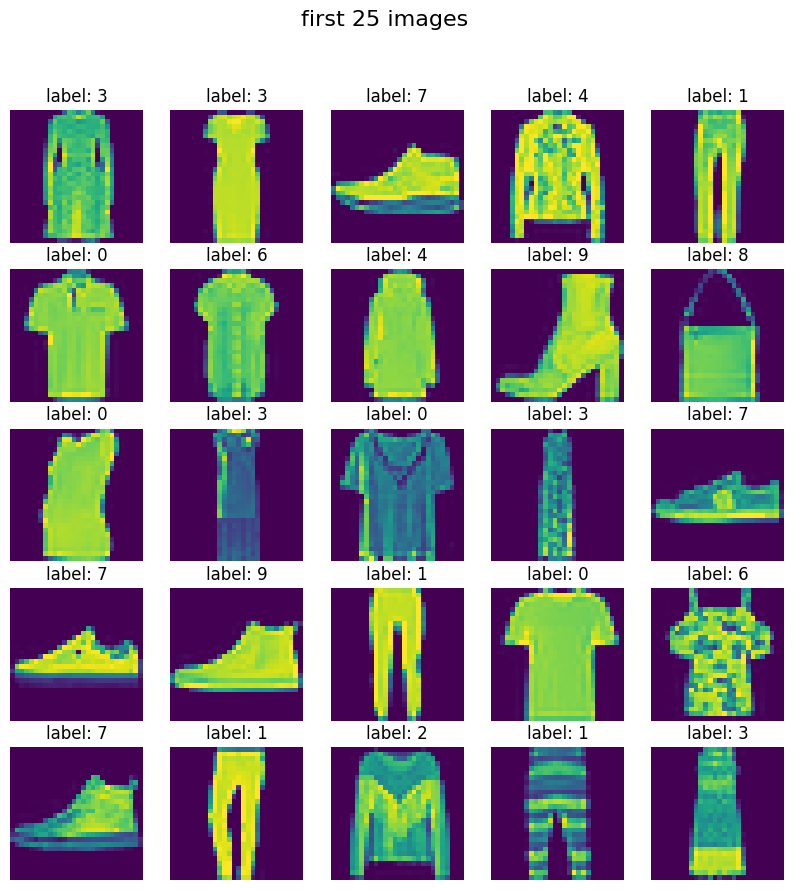

In [10]:
#to create 4x4 grid of data
fig, ax =plt.subplots(5,5, figsize=(10,10))
fig.suptitle("first 25 images", fontsize= 16)
for i, ax in enumerate(ax.flat):
    ax.imshow(df_10k.iloc[i,1:].values.reshape(28,28))
    ax.axis("off")
    ax.set_title(f"label: {df_10k.iloc[i,0]}")
plt.tight_layout
plt.show()

In [11]:
X= df_train.iloc[:,1:].values
y= df_train.iloc[:,0].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#standard scaler
"""from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)"""

#minmaxscaler
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

#labelencoder - NOT REQUIRED HERE


#to tensor
X_train_tensor= torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor= torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor= torch.tensor(y_train, dtype=torch.long)
y_test_tensor= torch.tensor(y_test, dtype=torch.long)

In [12]:
X_train_tensor.dtype

torch.float32

In [13]:
X_train_scaled.max(), X_train_scaled.min()

(np.float64(1.0), np.float64(0.0))

In [14]:
#create custom dataset
class custom_dataset(Dataset):
  def __init__(self, features, labels):
    self.features= features
    self.labels= labels
  def __len__(self):
    return len(self.features)
  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [15]:
#dataset
train_dataset= custom_dataset(X_train_tensor, y_train_tensor)
test_dataset= custom_dataset(X_test_tensor, y_test_tensor)

#dataloader
train_dataloader= DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_dataloader= DataLoader(test_dataset, batch_size=32, shuffle=False ,pin_memory=True) #to calculate accuracy

In [16]:
len(train_dataset)

48000

In [17]:
import torch.nn as nn
import torch.optim as optim

# The corrected mini_model class definition
class mini_model(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.model = nn.Sequential(
                nn.Linear(input_features, 128),
                # BATCH NORMALIZATION 0
                nn.BatchNorm1d(128),
                nn.ReLU(),

                #DROPOUT 1
                nn.Dropout(0.3),

                nn.Linear(128, 64),
                # BATCH NORMALIZATION1
                nn.BatchNorm1d(64),
                nn.ReLU(),

                #DROPOUT 2
                nn.Dropout(0.3),

                nn.Linear(64, 32),
                # BATCH NORMALIZATION 2
                nn.BatchNorm1d(32),
                nn.ReLU(),

                #DROPOUT 3
                nn.Dropout(0.3),
                nn.Linear(32, 10) # FIX: Changed from 64 to 32
                #nn.LogSoftmax(dim=1) CROSS ENTROPY LOSS GIVES SOFTMAX BY DEFAULT
        )

    def forward(self, features):
      return self.model(features)

In [18]:
#parameters
learning_rate= 0.01
epochs = 50
input_features = X_train_scaled.shape[1]

#REGULARIZATION WEIGHT DECAY
lambda1= 1e-4

input_features

784

In [19]:
#initialize  GPU model
model = mini_model(input_features)

#MDOEL TO GPU
model = model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay= lambda1)
#

In [21]:
# Re-initialize model with the corrected class
model = mini_model(input_features)

# MODEL TO GPU
model = model.to(device)

# Re-initialize optimizer because model parameters have changed
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay= lambda1)

# training loop
for epoch in range(epochs):

  total_epoch_loss= 0
  for batch_features, batch_label in train_dataloader:

    batch_features = batch_features.to(device)
    batch_label = batch_label.to(device)

    # forward pass
    outputs = model(batch_features)

    loss = criterion(outputs, batch_label)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update weights
    optimizer.step()
    total_epoch_loss += loss.item()

  print(total_epoch_loss)

  print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_dataloader):.4f}")

1590.3456622362137
Epoch 1/50, Loss: 1.0602
1058.131058305502
Epoch 2/50, Loss: 0.7054
941.9327526688576
Epoch 3/50, Loss: 0.6280
892.9960188567638
Epoch 4/50, Loss: 0.5953
849.7280724495649
Epoch 5/50, Loss: 0.5665
821.308226943016
Epoch 6/50, Loss: 0.5475
790.7400674968958
Epoch 7/50, Loss: 0.5272
779.8867180943489
Epoch 8/50, Loss: 0.5199
751.5051396489143
Epoch 9/50, Loss: 0.5010
742.7676214128733
Epoch 10/50, Loss: 0.4952
724.8769509196281
Epoch 11/50, Loss: 0.4833
712.4590657949448
Epoch 12/50, Loss: 0.4750
703.6014380604029
Epoch 13/50, Loss: 0.4691
689.9491138756275
Epoch 14/50, Loss: 0.4600
682.636795066297
Epoch 15/50, Loss: 0.4551
674.996710896492
Epoch 16/50, Loss: 0.4500
659.7172452136874
Epoch 17/50, Loss: 0.4398
657.8639729171991
Epoch 18/50, Loss: 0.4386
652.8872083798051
Epoch 19/50, Loss: 0.4353
639.4692544341087
Epoch 20/50, Loss: 0.4263
638.9762156754732
Epoch 21/50, Loss: 0.4260
631.0499337241054
Epoch 22/50, Loss: 0.4207
623.4816669225693
Epoch 23/50, Loss: 0.4157

In [22]:
# model eval
model.eval()

mini_model(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [23]:
#evaluation code train   for overfitting
total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_label in train_dataloader:

    batch_features = batch_features.to(device)
    batch_label = batch_label.to(device)

    outputs = model(batch_features)
      # to extract labels outta max outta probabilities
    _, predicted = torch.max(outputs.data, 1)
    total += batch_label.size(0)
    correct += (predicted == batch_label).sum().item()
print(f'Accuracy of the model on the 10000 test images: {100 * correct // total} %')


Accuracy of the model on the 10000 test images: 92 %


In [24]:
#evaluation code test
total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_label in test_dataloader:

    batch_features = batch_features.to(device)
    batch_label = batch_label.to(device)

    outputs = model(batch_features)
      # to extract labels outta max outta probabilities
    _, predicted = torch.max(outputs.data, 1)
    total += batch_label.size(0)
    correct += (predicted == batch_label).sum().item()
print(f'Accuracy of the model on the 10000 test images: {100 * correct // total} %')




Accuracy of the model on the 10000 test images: 89 %
